In [1]:

# NumPy:
# Used for numerical operations and handling MRI image arrays.
# Helps with normalization, matrix operations, and image dimensions.

# Pandas:
# Used for handling tables, CSV files, and storing model results.
# Helpful for performance reports and evaluation summaries.

# Matplotlib:
# Used for visualizing MRI images, segmentation masks, and training graphs.
# Helps display images and model outputs clearly.

# OpenCV:
# Used for image preprocessing like resizing and transformations.
# Helps prepare images before training the U-Net model.

# Scikit-learn:
# Used for train-test split and evaluation metrics.
# Helps in organizing data for proper model validation.

# PyTorch (Torch):
# Main deep learning library used to build and train the U-Net model.
# Handles model training, prediction, and saving trained models.

# Torchvision:
# Supports image transformations and preprocessing in PyTorch.
# Useful for normalization and data augmentation.

# Nibabel:
# Used for reading medical MRI files (.nii and .nii.gz).
# Essential for loading BraTS dataset images.

# Streamlit:
# Used to build the web application for tumor segmentation.
# Allows image upload, prediction, and result visualization.

# Pillow:
# Used for opening and handling image files.
# Helps display uploaded MRI images inside Streamlit.


In [2]:
# install libraries

!pip install numpy pandas matplotlib opencv-python scikit-learn
!pip install torch torchvision
!pip install nibabel
!pip install streamlit
!pip install pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 20.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 58.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.3/44.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 142.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.5/209.5 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 218.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.1/79.1 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 kB 9.7 MB/s eta 0:00:00
  Attempting uninstall: blinker
    Found existing installation: blinker 1.4
error: uninstall-distutils-installed-package

× Cannot uninstall blinker 1.4
╰─> It is a distutils installed project and thus we cannot accurately determine which files belong to it which would lead to only a partial uninstall.


In [3]:
# import libraries
import os
import cv2
import torch
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import TensorDataset, DataLoader
from sklearn.model_selection import train_test_split


In [4]:
!pip install kaggle

In [5]:
# Upload Kaggle API key
# Go to Kaggle → Account → Create API token
#Download kaggle.json

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"bincyjoby","key":"7ec18cb1efd2f2c9dfba585754849746"}'}

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [7]:
!pip install kaggle
!kaggle datasets download -d dschettler8845/brats-2021-task1

Dataset URL: https://www.kaggle.com/datasets/dschettler8845/brats-2021-task1
License(s): copyright-authors
100% 12.3G/12.3G [01:53<00:00, 117MB/s] 
100% 12.3G/12.3G [01:53<00:00, 117MB/s]


In [8]:
# Extract folder

import zipfile

with zipfile.ZipFile("brats-2021-task1.zip", 'r') as zip_ref:
    zip_ref.extractall("/content/dataset")

In [9]:
# .tar is only compressed storage.

import tarfile

tar_path = "/content/dataset/BraTS2021_Training_Data.tar"
extract_path = "/content/dataset/"

with tarfile.open(tar_path, "r") as tar:
    tar.extractall(path=extract_path)

print("Dataset extracted successfully!")

/tmp/ipython-input-1099273862.py:9: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Dataset extracted successfully!


In [10]:
# check extracted folder

import os

print(os.listdir("/content/dataset"))

['BraTS2021_00616', 'BraTS2021_01083', 'BraTS2021_01171', 'BraTS2021_01120', 'BraTS2021_00618', 'BraTS2021_00379', 'BraTS2021_01000', 'BraTS2021_01172', 'BraTS2021_00594', 'BraTS2021_00621.tar', 'BraTS2021_01415', 'BraTS2021_00089', 'BraTS2021_00780', 'BraTS2021_00728', 'BraTS2021_00343', 'BraTS2021_00587', 'BraTS2021_01279', 'BraTS2021_01075', 'BraTS2021_01340', 'BraTS2021_00436', 'BraTS2021_01104', 'BraTS2021_00756', 'BraTS2021_01011', 'BraTS2021_01565', 'BraTS2021_01314', 'BraTS2021_00810', 'BraTS2021_00209', 'BraTS2021_01350', 'BraTS2021_01608', 'BraTS2021_01267', 'BraTS2021_00625', 'BraTS2021_00579', 'BraTS2021_00472', 'BraTS2021_00731', 'BraTS2021_00157', 'BraTS2021_01625', 'BraTS2021_01030', 'BraTS2021_00759', 'BraTS2021_01420', 'BraTS2021_00750', 'BraTS2021_01036', 'BraTS2021_01115', 'BraTS2021_00217', 'BraTS2021_00395', 'BraTS2021_00733', 'BraTS2021_00402', 'BraTS2021_01118', 'BraTS2021_01064', 'BraTS2021_00656', 'BraTS2021_01550', 'BraTS2021_00103', 'BraTS2021_00035', 'BraTS2

In [11]:
print(os.listdir("/content/dataset"))

['BraTS2021_00616', 'BraTS2021_01083', 'BraTS2021_01171', 'BraTS2021_01120', 'BraTS2021_00618', 'BraTS2021_00379', 'BraTS2021_01000', 'BraTS2021_01172', 'BraTS2021_00594', 'BraTS2021_00621.tar', 'BraTS2021_01415', 'BraTS2021_00089', 'BraTS2021_00780', 'BraTS2021_00728', 'BraTS2021_00343', 'BraTS2021_00587', 'BraTS2021_01279', 'BraTS2021_01075', 'BraTS2021_01340', 'BraTS2021_00436', 'BraTS2021_01104', 'BraTS2021_00756', 'BraTS2021_01011', 'BraTS2021_01565', 'BraTS2021_01314', 'BraTS2021_00810', 'BraTS2021_00209', 'BraTS2021_01350', 'BraTS2021_01608', 'BraTS2021_01267', 'BraTS2021_00625', 'BraTS2021_00579', 'BraTS2021_00472', 'BraTS2021_00731', 'BraTS2021_00157', 'BraTS2021_01625', 'BraTS2021_01030', 'BraTS2021_00759', 'BraTS2021_01420', 'BraTS2021_00750', 'BraTS2021_01036', 'BraTS2021_01115', 'BraTS2021_00217', 'BraTS2021_00395', 'BraTS2021_00733', 'BraTS2021_00402', 'BraTS2021_01118', 'BraTS2021_01064', 'BraTS2021_00656', 'BraTS2021_01550', 'BraTS2021_00103', 'BraTS2021_00035', 'BraTS2

In [12]:
# set dataset path

DATASET_PATH = "/content/dataset"



# .nii = medical MRI format (Neuroimaging file)
# .gz = compressed version

# flair.nii.gz = FLAIR MRI scan (compressed)

# FLAIR stands for: Fluid Attenuated Inversion Recovery

# BraTS_xxx_flair.nii.gz, This is what we give to the model

# BraTS_xxx_seg.nii.gz, This is the ground truth mask (tumor region)

# Each patient folder = one brain scan
# FLAIR = input MRI image
# SEG = tumor label (ground truth)
# .nii.gz = compressed medical image format
# convert it into 2D images for U-Net

In [13]:
# load MRI file (.nii.gz)


import nibabel as nib

def load_nifti(path):
    img = nib.load(path)
    data = img.get_fdata()
    return data





In [14]:
# get patient paths

def get_patient_paths():
    patients = []

    for folder in os.listdir(DATASET_PATH):
        folder_path = os.path.join(DATASET_PATH, folder)

        if os.path.isdir(folder_path):
            flair_path = None
            mask_path = None

            for file in os.listdir(folder_path):
                file_lower = file.lower()

                if "flair" in file_lower:
                    flair_path = os.path.join(folder_path, file)

                if "seg" in file_lower:
                    mask_path = os.path.join(folder_path, file)

            if flair_path and mask_path:
                patients.append((flair_path, mask_path))

    return patients

In [15]:
# get patient paths

patients = get_patient_paths()

print("Total patients:", len(patients))
print("First patient:", patients[0])

Total patients: 1251
First patient: ('/content/dataset/BraTS2021_00616/BraTS2021_00616_flair.nii.gz', '/content/dataset/BraTS2021_00616/BraTS2021_00616_seg.nii.gz')


In [16]:
# load one patient


flair_path, mask_path = patients[0]

flair = load_nifti(flair_path)
mask = load_nifti(mask_path)

print("FLAIR shape:", flair.shape)
print("Mask shape:", mask.shape)

FLAIR shape: (240, 240, 155)
Mask shape: (240, 240, 155)


In [17]:
# Extract Useful Middle Slices



def extract_slices(volume, start=60, end=100):
    slices = []

    for i in range(start, end):
        slices.append(volume[:, :, i])

    return slices

In [18]:
# Extract slices


#  Extracts middle 2D slices from a 3D MRI volume.
# This helps convert volumetric MRI data into usable images for deep learning models like U-Net.

flair_slices = extract_slices(flair)
mask_slices = extract_slices(mask)

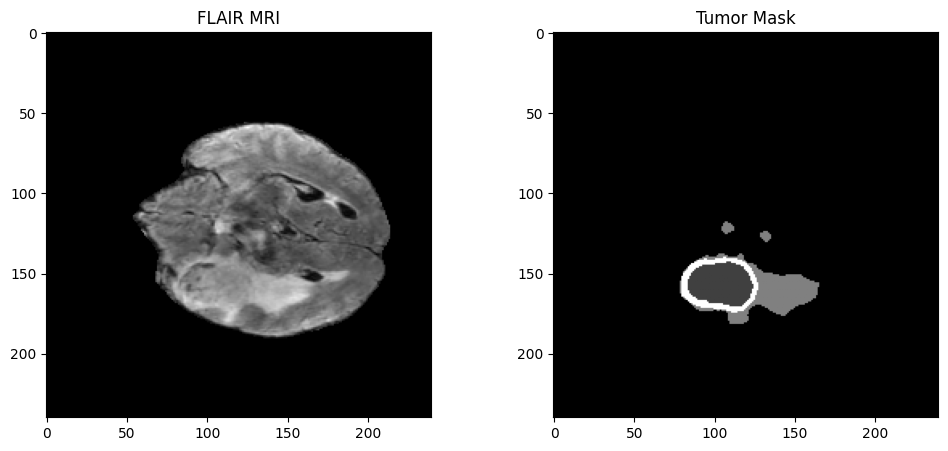

In [19]:
# Display MRI, mask

import matplotlib.pyplot as plt

# choose a slice index from extracted slices
i = 10

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.title("FLAIR MRI")
plt.imshow(flair_slices[i], cmap="gray")

plt.subplot(1,2,2)
plt.title("Tumor Mask")
plt.imshow(mask_slices[i], cmap="gray")

plt.show()

In [20]:
# Preprocess Images



def preprocess(image):
    image = cv2.resize(image, (128, 128))

    if np.max(image) != 0:
        image = image / np.max(image)

    return image.astype(np.float32)



In [21]:
#  Preprocess Masks



def preprocess_mask(mask):
    mask = cv2.resize(mask, (128, 128))

    # Convert all tumor labels to binary
    mask = (mask > 0).astype(np.float32)

    return mask

In [22]:
 # Prepare Dataset

def prepare_dataset():
    X = []
    Y = []

    patient_data = get_patient_paths()[:10]  # use only first 10 patients
    print("Total patients found:", len(patient_data))

    for flair_path, mask_path in patient_data:
        flair_volume = load_nifti(flair_path)
        mask_volume = load_nifti(mask_path)

        flair_slices = extract_slices(flair_volume)
        mask_slices = extract_slices(mask_volume)

        for img, mask in zip(flair_slices, mask_slices):
            img = preprocess(img)
            mask = preprocess_mask(mask)

            X.append(img)
            Y.append(mask)

    return np.array(X, dtype=np.float32), np.array(Y, dtype=np.float32)

In [23]:
X, Y = prepare_dataset()

Total patients found: 10


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2)

In [25]:
import torch
import torch.nn as nn

In [27]:
 # Build U-Net Model



class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(DoubleConv, self).__init__()

        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)


class UNet(nn.Module):
    def __init__(self):
        super(UNet, self).__init__()

        self.down1 = DoubleConv(1, 64)
        self.pool1 = nn.MaxPool2d(2)
        self.down2 = DoubleConv(64, 128)
        self.pool2 = nn.MaxPool2d(2)

        self.bottleneck = DoubleConv(128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, 2, stride=2)
        self.conv2 = DoubleConv(256, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, 2, stride=2)
        self.conv1 = DoubleConv(128, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        c1 = self.down1(x)
        p1 = self.pool1(c1)

        c2 = self.down2(p1)
        p2 = self.pool2(c2)
        bn = self.bottleneck(p2)

        u2 = self.up2(bn)
        u2 = torch.cat([u2, c2], dim=1)
        c3 = self.conv2(u2)

        u1 = self.up1(c3)
        u1 = torch.cat([u1, c1], dim=1)
        c4 = self.conv1(u1)

        output = self.final(c4)
        return self.sigmoid(output)


In [28]:
# Prepare DataLoader


X_train = torch.tensor(X_train).unsqueeze(1).float()
Y_train = torch.tensor(Y_train).unsqueeze(1).float()

train_dataset = TensorDataset(X_train, Y_train)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)



In [29]:
# Train Model

model = UNet()
criterion = torch.nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 25

for epoch in range(EPOCHS):
    model.train()
    total_loss = 0

    for images, masks in train_loader:
        predictions = model(images)
        loss = criterion(predictions, masks)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()


print(f"Epoch {epoch+1}/{EPOCHS}, Loss: {total_loss:.4f}")



Epoch 25/25, Loss: 0.6180


In [30]:
 # Save Model


torch.save(model.state_dict(), "model.pth")
print("Model saved successfully!")


Model saved successfully!


In [31]:
# Download Model from Colab

from google.colab import files
files.download("model.pth")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [32]:
 # Quick Prediction Test


model.eval()

sample = X_test[0]
sample_tensor = torch.tensor(sample).unsqueeze(0).unsqueeze(0).float()

with torch.no_grad():
    prediction = model(sample_tensor)

pred_mask = prediction.squeeze().numpy()



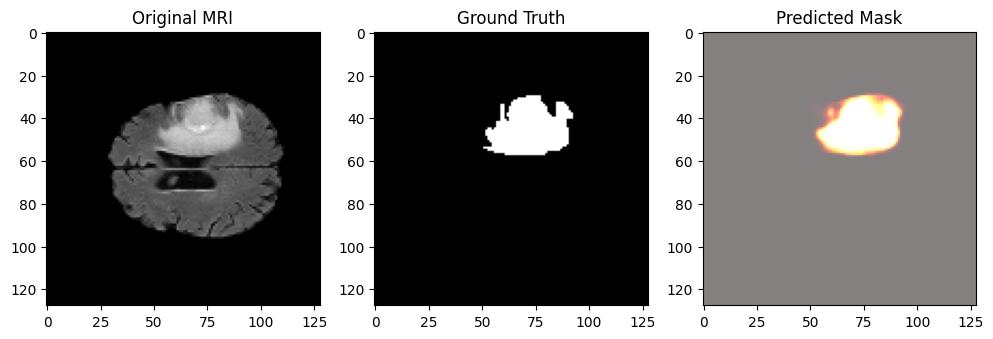

In [33]:
#Visualize Result


plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title("Original MRI")
plt.imshow(sample, cmap="gray")

plt.subplot(1, 3, 2)
plt.title("Ground Truth")
plt.imshow(Y_test[0], cmap="gray")

plt.subplot(1, 3, 3)
plt.title("Predicted Mask")
# plt.imshow(pred_mask, cmap="gray")

plt.imshow(pred_mask, cmap="hot", alpha=0.5)

plt.show()


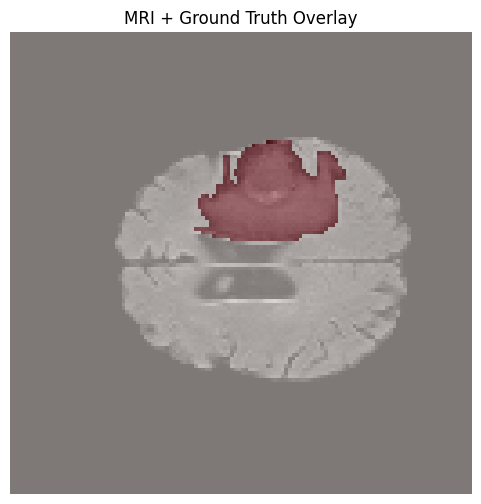

In [35]:
# MRI, Ground truth overlay

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.title("MRI + Ground Truth Overlay")

plt.imshow(sample, cmap="gray")
plt.imshow(Y_test[0], cmap="Reds", alpha=0.5)

plt.axis("off")
plt.show()


# Gray = MRI brain
#Red = tumor mask
#alpha=0.5 = transparency

# You now see tumor location directly on brain#

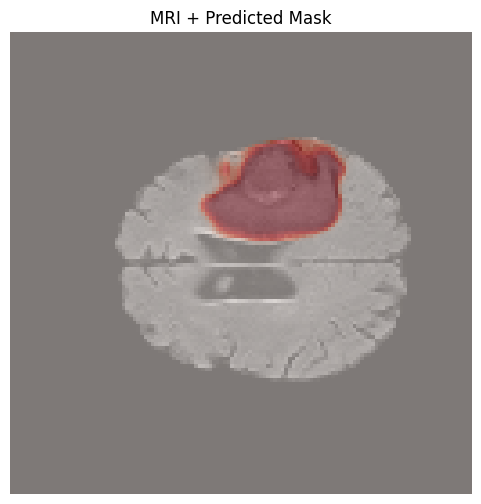

In [36]:
# MRI, Prediction overlay
plt.figure(figsize=(6,6))

plt.title("MRI + Predicted Mask")

plt.imshow(sample, cmap="gray")
plt.imshow(pred_mask, cmap="Reds", alpha=0.5)

plt.axis("off")
plt.show()

In [37]:
# Dice score most important metric

import numpy as np

def dice_score(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    intersection = np.sum(y_true * y_pred)

    return (2. * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-8)

In [38]:
score = dice_score(Y_test[0], pred_mask)
print("Dice Score:", score)

Dice Score: 0.89896685
